In [1]:
import warnings
warnings.filterwarnings('ignore')

from nrem_sc.constants import PROCESSED_DATA_PATH, INTERIM_DATA_PATH
from nrem_sc.utils import plot_intervals, circ_bin_average

import numpy as np
import pynapple as nap
import seaborn as sns
import umap
import umap.plot as uplot

from matplotlib import pyplot as plt

# Parameters
WAKE_BIN = 0.2
SMOOTH_STD = 0.4
UMAP_NEIGHBORS = 250
UMAP_MIN_DIST = 0.2

Load unit data

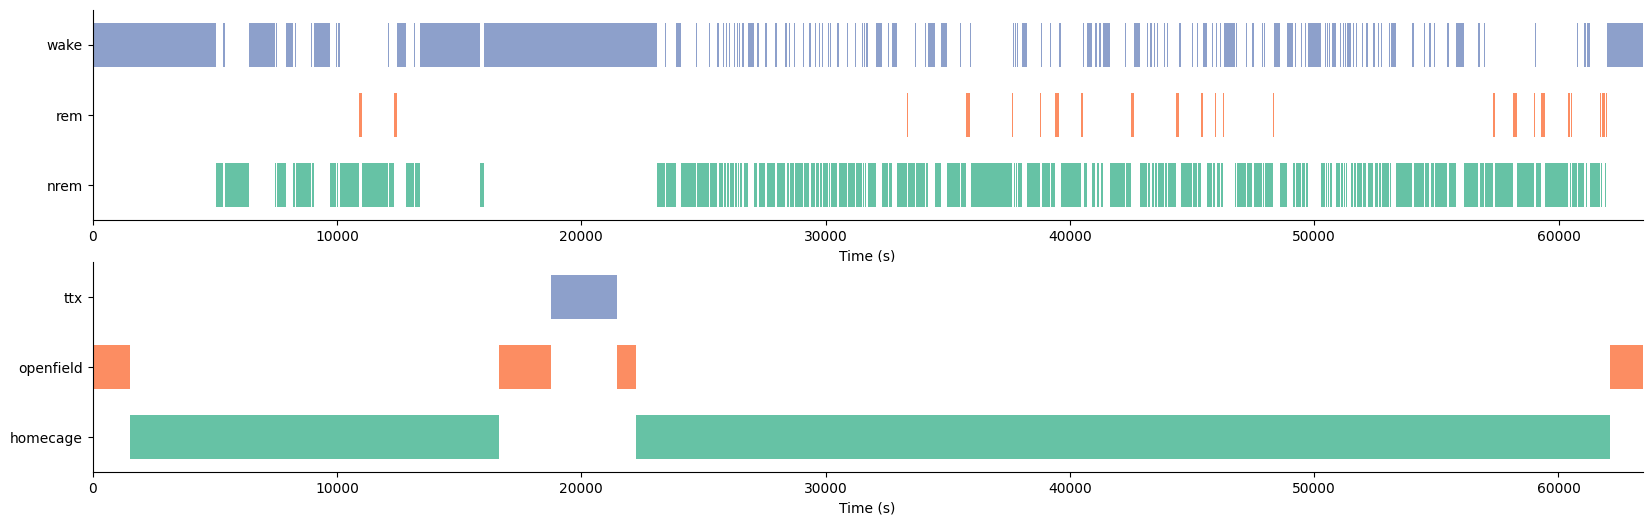

In [2]:
unit_id = "116b"
sleep_states    = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sleep.npz")
hd_spikes       = nap.load_file(PROCESSED_DATA_PATH / unit_id / "hd_spikes_filtered.npz")
hd_angle        = nap.load_file(PROCESSED_DATA_PATH / unit_id / "angle_openfield.npz")
sessions        = nap.load_file(PROCESSED_DATA_PATH / unit_id / "sessions_labeled.npz")

# Plot sleep states and sessions for the unit
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(20, 6))

plot_intervals(sleep_states, column='state', palette='Set2', ax=ax1)
plot_intervals(sessions, column='label', palette='Set2', ax=ax2)

plt.show()

#### Pre vs Post TTX injection wake manifolds

wake_rates shape: (10548, 81)


<Axes: >

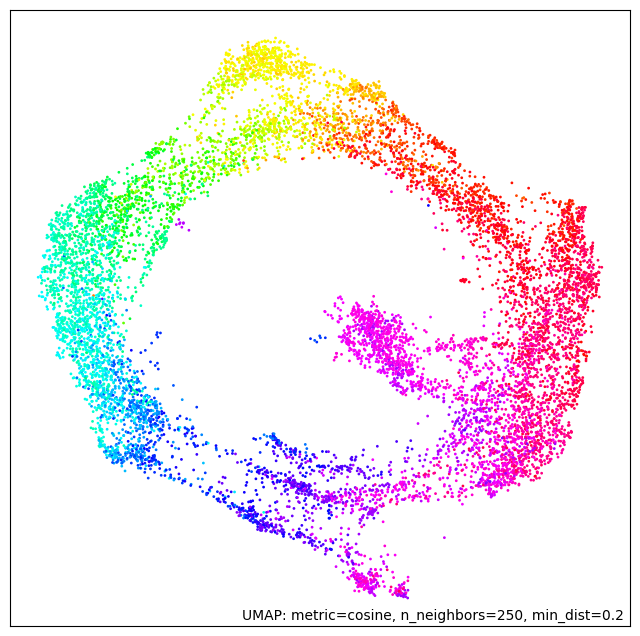

In [5]:
epochs = sessions[sessions['label'] == 'openfield']
binned = hd_spikes.count(bin_size=WAKE_BIN, ep=hd_angle.time_support)
wake_rates = np.sqrt(binned.smooth(std=SMOOTH_STD))
angle = circ_bin_average(hd_angle, bin_size=WAKE_BIN)
print(f"wake_rates shape: {wake_rates.shape}")

reducer = umap.UMAP(n_neighbors=UMAP_NEIGHBORS, min_dist=UMAP_MIN_DIST, n_components=2, metric='cosine')
reducer.fit(wake_rates)
uplot.points(reducer, values=angle.values, cmap='hsv')

In [75]:
epoch = sessions[sessions['label'] == 'openfield'][2]
binned = hd_spikes.count(bin_size=WAKE_BIN, ep=epoch)
post_wake = np.sqrt(binned.smooth(std=SMOOTH_STD))
print(f"post_ttx: {post_wake.shape}")

post_ttx: (3951, 81)


In [76]:
post_embds = reducer.transform(post_wake)

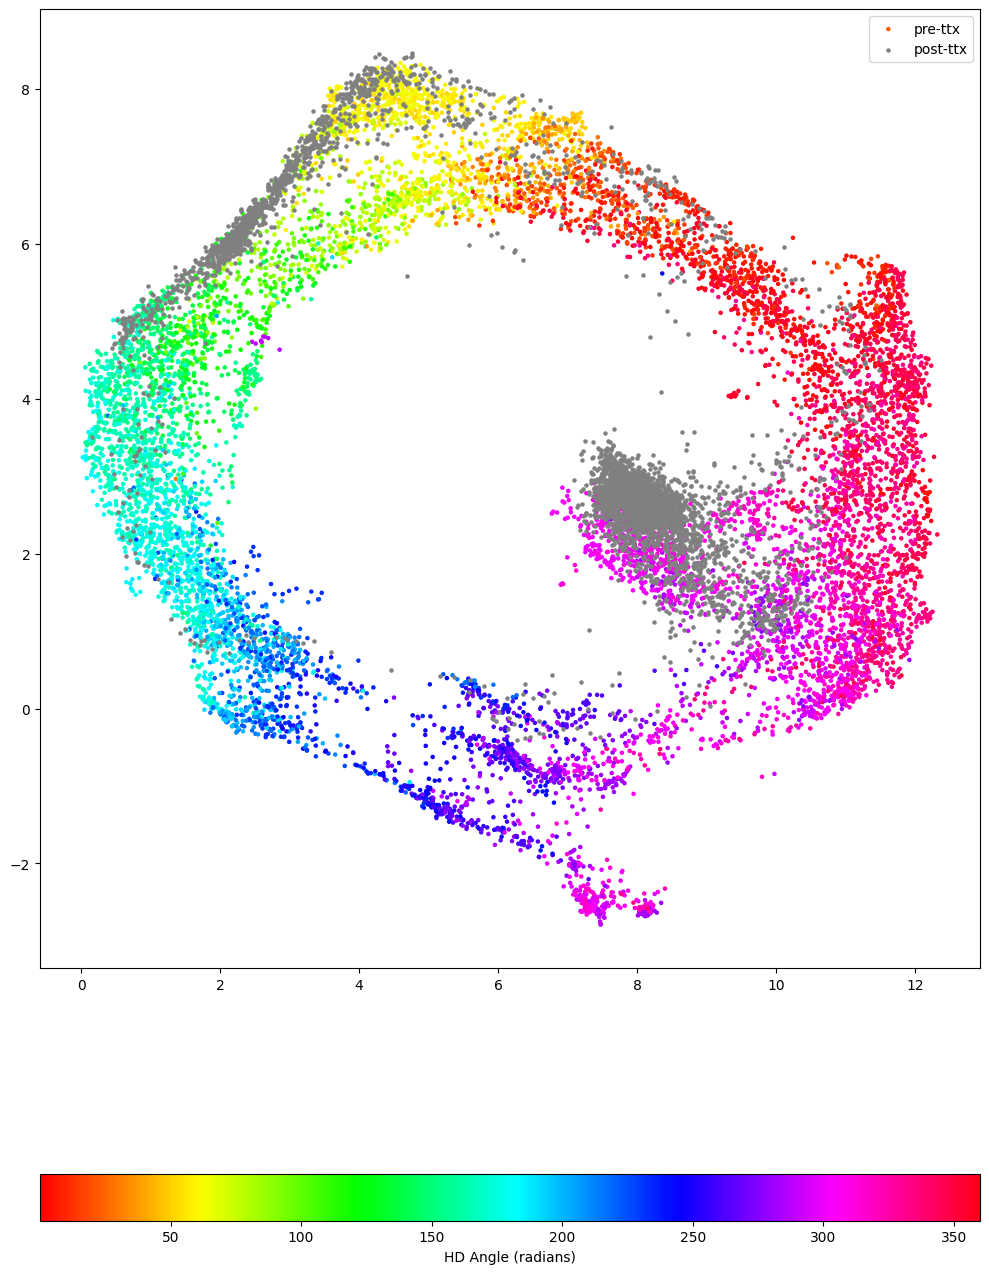

In [90]:
fig, ax = plt.subplots(figsize=(10, 14))
plt.rcParams["figure.figsize"] = [7.50, 3.50]
plt.rcParams["figure.autolayout"] = True

points = ax.scatter(x=reducer.embedding_[:, 0], y=reducer.embedding_[:, 1], label='pre-ttx', s=5, c=angle.values, cmap='hsv')
ax.scatter(x=post_embds[:, 0], y=post_embds[:, 1], label='post-ttx', s=5, c='grey')

fig.colorbar(points, orientation='horizontal', label='HD Angle (radians)')
plt.legend()
plt.show()

In [ ]:
epochs = sessions[sessions['label'] == 'openfield']
binned = hd_spikes.count(bin_size=WAKE_BIN, ep=epochs)
wake_rates = np.sqrt(binned.smooth(std=SMOOTH_STD))
print(f"wake_rates shape: {wake_rates.shape}")

<Axes: >

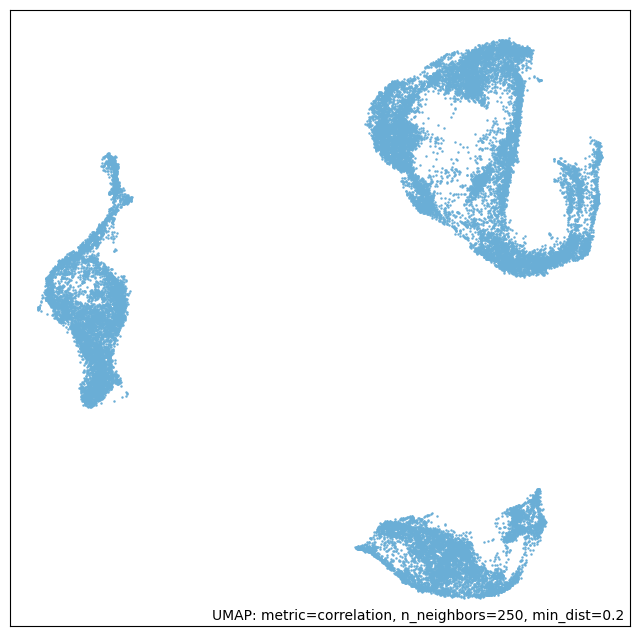

In [ ]:
reducer = umap.UMAP(n_neighbors=UMAP_NEIGHBORS, min_dist=UMAP_MIN_DIST, n_components=2, metric='correlation')
reducer.fit(wake_rates)
uplot.points(reducer)

In [57]:
times = wake_rates.t.copy()
labels = np.zeros_like(times, dtype=np.uint8)
for i in range(len(sessions[sessions['label'] == 'openfield'])):
    t_offset = sessions[sessions['label'] == 'openfield'][i]['end']
    labels[times > t_offset] += 1
labels

array([0, 0, 0, ..., 3, 3, 3], shape=(29074,), dtype=uint8)

<Axes: >

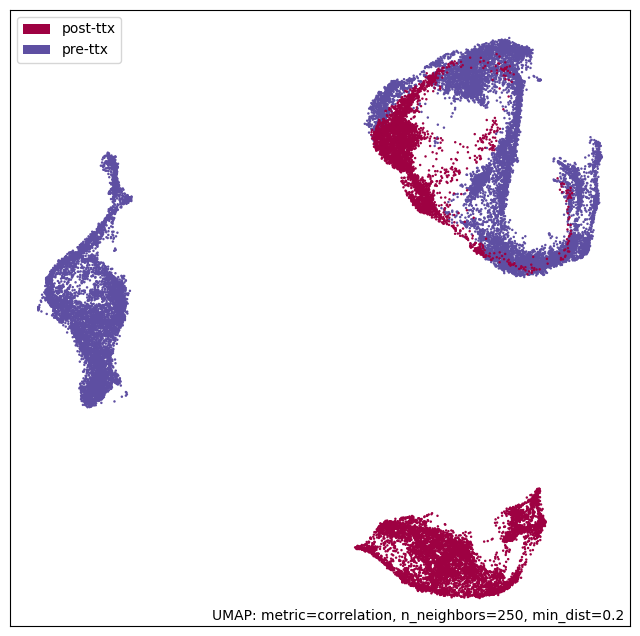

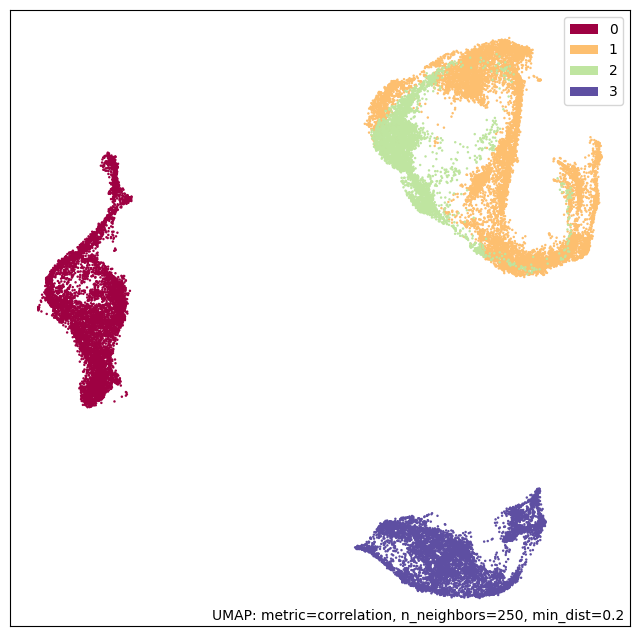

In [59]:
ttx_onset = sessions[sessions['label'] == 'ttx']['start'].item()
uplot.points(reducer, labels=np.where(wake_rates.t < ttx_onset, 'pre-ttx', 'post-ttx'), cmap='Set1')
uplot.points(reducer, labels=labels, cmap='Set1')